<a href="https://colab.research.google.com/github/tahermatbouly/Credit-Card-Fraud-Detection/blob/main/Credit_Card_Fraud_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Credit Card Fraud Detection**
##An AI tool that simulates an attack on a transaction then it detects and evaluate fraud and blocks it using classical ML and DL

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#**Dealing with the data and Doing some Presprocessing**

In [ ]:
data = pd.read_csv("/content/paysim.csv")

In [ ]:
data.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0.0,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0,0.0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1.0,0.0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1.0,0.0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0.0,0.0


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 165439 entries, 0 to 165438
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   step            165439 non-null  int64  
 1   type            165439 non-null  object 
 2   amount          165439 non-null  float64
 3   nameOrig        165439 non-null  object 
 4   oldbalanceOrg   165439 non-null  float64
 5   newbalanceOrig  165439 non-null  float64
 6   nameDest        165439 non-null  object 
 7   oldbalanceDest  165438 non-null  float64
 8   newbalanceDest  165438 non-null  float64
 9   isFraud         165438 non-null  float64
 10  isFlaggedFraud  165438 non-null  float64
dtypes: float64(7), int64(1), object(3)
memory usage: 13.9+ MB


In [ ]:
data.isna().sum()

,0
step,0
type,0
amount,0
nameOrig,0
oldbalanceOrg,0
newbalanceOrig,0
nameDest,0
oldbalanceDest,1
newbalanceDest,1
isFraud,1


In [ ]:
data["step"]

,step
0,1
1,1
2,1
3,1
4,1
...,...
165434,12
165435,12
165436,12
165437,12


In [ ]:
data.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [ ]:
data.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
165434,False
165435,False
165436,False
165437,False


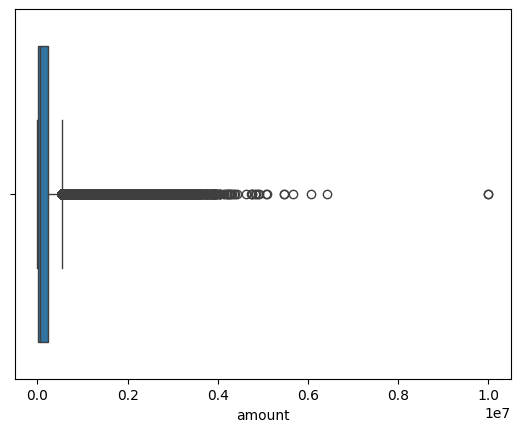

In [ ]:
sns.boxplot(x=data['amount'])
plt.show()

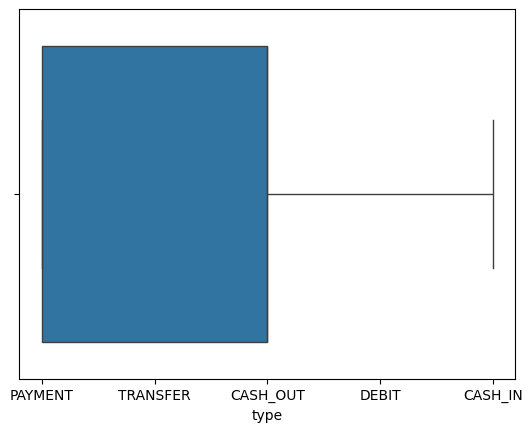

In [ ]:
sns.boxplot(x=data['type'])
plt.show()

In [ ]:
data['balance_diff_orig'] = data['newbalanceOrig'] - data['oldbalanceOrg']
data['balance_diff_dest'] = data['newbalanceDest'] - data['oldbalanceDest']

In [ ]:
data.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balance_diff_orig,balance_diff_dest
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0.0,0.0,-9839.64,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0,0.0,-1864.28,0.0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1.0,0.0,-181.00,0.0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1.0,0.0,-181.00,-21182.0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0.0,0.0,-11668.14,0.0


In [ ]:
data.drop(['oldbalanceOrg', 'newbalanceOrig',
           'oldbalanceDest', 'newbalanceDest'], axis=1, inplace=True)

In [ ]:
data.head()

,step,type,amount,nameOrig,nameDest,isFraud,isFlaggedFraud,balance_diff_orig,balance_diff_dest
0,1,PAYMENT,9839.64,C1231006815,M1979787155,0.0,0.0,-9839.64,0.0
1,1,PAYMENT,1864.28,C1666544295,M2044282225,0.0,0.0,-1864.28,0.0
2,1,TRANSFER,181.00,C1305486145,C553264065,1.0,0.0,-181.00,0.0
3,1,CASH_OUT,181.00,C840083671,C38997010,1.0,0.0,-181.00,-21182.0
4,1,PAYMENT,11668.14,C2048537720,M1230701703,0.0,0.0,-11668.14,0.0


In [ ]:
data = pd.get_dummies(data, columns=['type'], drop_first=True)

In [ ]:
data.head()

,step,amount,nameOrig,nameDest,isFraud,isFlaggedFraud,balance_diff_orig,balance_diff_dest,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,1,9839.64,C1231006815,M1979787155,0.0,0.0,-9839.64,0.0,False,False,True,False
1,1,1864.28,C1666544295,M2044282225,0.0,0.0,-1864.28,0.0,False,False,True,False
2,1,181.00,C1305486145,C553264065,1.0,0.0,-181.00,0.0,False,False,False,True
3,1,181.00,C840083671,C38997010,1.0,0.0,-181.00,-21182.0,True,False,False,False
4,1,11668.14,C2048537720,M1230701703,0.0,0.0,-11668.14,0.0,False,False,True,False


In [ ]:
hour = data["step"] % 24
day = data["step"] // 24
is_night = (hour < 6)

In [ ]:
data['amount'].mean()

np.float64(179349.60335132587)

In [ ]:
data['is_high_amount'] = (data['amount'] > data['amount'].mean()).astype(int)

In [ ]:
data["is_high_amount"]

,is_high_amount
0,0
1,0
2,0
3,0
4,0
...,...
165434,0
165435,0
165436,0
165437,1


In [ ]:
data.head(30)

,step,amount,nameOrig,nameDest,isFraud,isFlaggedFraud,balance_diff_orig,balance_diff_dest,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER,is_high_amount
0,1,9839.64,C1231006815,M1979787155,0.0,0.0,-9839.64,0.00,False,False,True,False,0
1,1,1864.28,C1666544295,M2044282225,0.0,0.0,-1864.28,0.00,False,False,True,False,0
2,1,181.00,C1305486145,C553264065,1.0,0.0,-181.00,0.00,False,False,False,True,0
3,1,181.00,C840083671,C38997010,1.0,0.0,-181.00,-21182.00,True,False,False,False,0
4,1,11668.14,C2048537720,M1230701703,0.0,0.0,-11668.14,0.00,False,False,True,False,0
5,1,7817.71,C90045638,M573487274,0.0,0.0,-7817.71,0.00,False,False,True,False,0
6,1,7107.77,C154988899,M408069119,0.0,0.0,-7107.77,0.00,False,False,True,False,0
7,1,7861.64,C1912850431,M633326333,0.0,0.0,-7861.64,0.00,False,False,True,False,0
8,1,4024.36,C1265012928,M1176932104,0.0,0.0,-2671.00,0.00,False,False,True,False,0
9,1,5337.77,C712410124,C195600860,0.0,0.0,-5337.77,-1549.21,False,True,False,False,0


<Axes: xlabel='amount', ylabel='Count'>

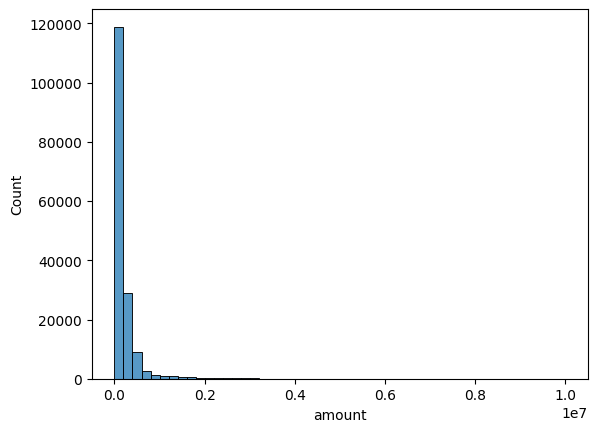

In [ ]:
sns.histplot(data['amount'], bins=50)

#**Fraud is detected in high scaled data "amounts" , we are going to apply a normalization methid for the data which is Log Transformation**

In [ ]:
data['amount_log'] = np.log1p(data['amount'])

In [ ]:
data.head()

,step,amount,nameOrig,nameDest,isFraud,isFlaggedFraud,balance_diff_orig,balance_diff_dest,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER,is_high_amount,amount_log
0,1,9839.64,C1231006815,M1979787155,0.0,0.0,-9839.64,0.0,False,False,True,False,0,9.194276
1,1,1864.28,C1666544295,M2044282225,0.0,0.0,-1864.28,0.0,False,False,True,False,0,7.531166
2,1,181.00,C1305486145,C553264065,1.0,0.0,-181.00,0.0,False,False,False,True,0,5.204007
3,1,181.00,C840083671,C38997010,1.0,0.0,-181.00,-21182.0,True,False,False,False,0,5.204007
4,1,11668.14,C2048537720,M1230701703,0.0,0.0,-11668.14,0.0,False,False,True,False,0,9.364703


<Axes: xlabel='amount_log', ylabel='Count'>

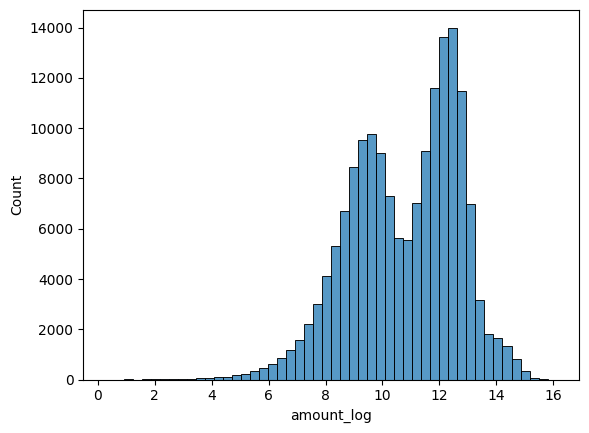

In [ ]:
sns.histplot(data['amount_log'], bins=50)

#**Converting the categorical to int in the type columns**

In [ ]:
data[['type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER']] = \
data[['type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER']].astype(int)

In [ ]:
data.head()

,step,amount,nameOrig,nameDest,isFraud,isFlaggedFraud,balance_diff_orig,balance_diff_dest,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER,is_high_amount,amount_log
0,1,9839.64,C1231006815,M1979787155,0.0,0.0,-9839.64,0.0,0,0,1,0,0,9.194276
1,1,1864.28,C1666544295,M2044282225,0.0,0.0,-1864.28,0.0,0,0,1,0,0,7.531166
2,1,181.00,C1305486145,C553264065,1.0,0.0,-181.00,0.0,0,0,0,1,0,5.204007
3,1,181.00,C840083671,C38997010,1.0,0.0,-181.00,-21182.0,1,0,0,0,0,5.204007
4,1,11668.14,C2048537720,M1230701703,0.0,0.0,-11668.14,0.0,0,0,1,0,0,9.364703
